# Feature Engineering First Pass

Goal: build an explainable first feature matrix for next-day streamflow at USGS 05532500. This notebook keeps the work exploratory, then calls the reusable implementation in `streamflow.features` so it can move into the pipeline later.

Feature families included here:

- streamflow memory: current day, lags, and rolling 3/7/14/30 day summaries
- precipitation memory: rolling sums and means, especially 3-day accumulation
- temperature: daily mean/range plus rolling mean weather context
- seasonality: day-of-year sine/cosine
- anomaly marker: top 1% high-flow days, useful for flagging flood events without assuming they should trigger retraining
- target: `log1p(next-day streamflow_cfs)`

## Feature Explanation Table

| Feature / Feature Family | Examples | Meaning | Why it helps |
|---|---|---|---|
| Current streamflow | `streamflow_t`, `log_streamflow_t` | Streamflow on prediction day `t` | Strong baseline signal because tomorrow's flow is usually related to today's flow |
| Streamflow lags | `streamflow_lag_1`, `streamflow_lag_3`, `streamflow_lag_7`, `streamflow_lag_30` | Streamflow from previous days | Captures recent river memory and delayed hydrologic response |
| Log streamflow lags | `log_streamflow_lag_1`, `log_streamflow_lag_7` | Log-transformed lagged flow | Reduces the influence of extreme flood values and skew |
| Rolling streamflow mean | `streamflow_roll_mean_7d`, `streamflow_roll_mean_30d` | Average flow over recent windows | Captures short-term and monthly flow trend |
| Rolling streamflow std | `streamflow_roll_std_7d`, `streamflow_roll_std_30d` | Variability in recent streamflow | Helps identify unstable periods or rapid changes |
| Rolling streamflow min/max | `streamflow_roll_min_30d`, `streamflow_roll_max_30d` | Recent low/high flow range | Captures recent extremes in the river state |
| Precipitation sums | `precip_sum_3d`, `precip_sum_7d`, `precip_sum_30d` | Accumulated recent rainfall | Rainfall is a direct driver of streamflow increases |
| Precipitation means | `precip_mean_7d`, `precip_mean_30d` | Average recent rainfall | Captures wet versus dry recent conditions |
| Temperature features | `temp_mean_c`, `temp_range_c` | Daily average temperature and temperature spread | Adds weather and seasonal context |
| Rolling temperature | `temp_mean_roll_7d`, `temp_mean_roll_30d` | Recent average temperature | Helps model seasonal flow patterns |
| Seasonality | `day_of_year_sin`, `day_of_year_cos` | Cyclical encoding of time of year | Captures annual patterns while keeping Dec 31 and Jan 1 close together |
| Month | `month` | Calendar month | Simple seasonal indicator |
| Flood anomaly flag | `is_high_flow_anomaly` | 1 if current flow is in the historical top 1% | Lets us highlight floods as anomalies to investigate, not automatic retraining triggers |
| Target | `target_log_streamflow_next_day` | `log1p` of tomorrow's streamflow | Prediction target for the model |


In [10]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from streamflow.config import CONFIG, resolve
from streamflow.features import TARGET_COLUMN, build_features

In [11]:
raw_path = resolve(CONFIG["data"]["raw_path"])
raw = pd.read_parquet(raw_path)
raw.head()

,date,streamflow_cfs,approval_status,qualifier,last_modified,precip_mm,tmax_c,tmin_c
0,1944-01-01,31.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,3.4,-5.6
1,1944-01-02,45.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,2.9,-4.2
2,1944-01-03,33.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,3.3,-3.2
3,1944-01-04,38.0,Approved,None,2025-02-24 12:43:19.306975+00:00,0.0,3.2,-3.2
4,1944-01-05,29.0,Approved,None,2025-02-24 12:43:19.306975+00:00,2.1,1.8,-3.5


In [12]:
raw.shape, raw["date"].min(), raw["date"].max(), raw.isna().sum().sort_values(ascending=False).head(10)

((30155, 8),
 Timestamp('1944-01-01 00:00:00'),
 Timestamp('2026-07-25 00:00:00'),
 qualifier          29180
 date                   0
 streamflow_cfs         0
 approval_status        0
 last_modified          0
 precip_mm              0
 tmax_c                 0
 tmin_c                 0
 dtype: int64)

In [13]:
features = build_features(raw)
features.shape, len(features.attrs["feature_columns"]), TARGET_COLUMN

((30124, 56), 49, 'target_log_streamflow_next_day')

In [14]:
features[["date", "streamflow_t", "streamflow_lag_1", "streamflow_roll_mean_7d", "precip_sum_3d", TARGET_COLUMN]].head()

,date,streamflow_t,streamflow_lag_1,streamflow_roll_mean_7d,precip_sum_3d,target_log_streamflow_next_day
0,1944-01-31,54.0,80.0,54.714286,9.2,3.970292
1,1944-02-01,52.0,54.0,57.714286,9.2,3.912023
2,1944-02-02,49.0,52.0,59.000000,9.7,3.761200
3,1944-02-03,42.0,49.0,57.285714,0.5,3.828641
4,1944-02-04,45.0,42.0,55.142857,0.5,4.043051


In [15]:
feature_preview = pd.Series(features.attrs["feature_columns"], name="feature")
feature_preview.head(30).to_frame()

,feature
0,precip_mm
1,tmax_c
2,tmin_c
3,streamflow_t
4,log_streamflow_t
5,streamflow_lag_1
6,log_streamflow_lag_1
7,streamflow_lag_2
8,log_streamflow_lag_2
9,streamflow_lag_3


#### keep seasonal encoding to month plus day-of-year sine/cosine

XGBoost note: we keep raw numeric features plus log-transformed streamflow features. Tree-based XGBoost does not need z-score scaling, and skipping it keeps the feature matrix easier to interpret while avoiding another preprocessing step.

In [16]:
zscore_cols = [col for col in features.columns if col.endswith("_z")]
zscore_cols

[]

Flood/anomaly note: high-flow days are marked with a top-1% threshold. This gives the presentation a concrete way to discuss floods as anomalies that should be investigated separately, not automatically treated as data drift requiring retraining.

In [17]:
high_flow = features.loc[features["is_high_flow_anomaly"] == 1, ["date", "streamflow_t", "precip_sum_3d"]]
high_flow.head()

,date,streamflow_t,precip_sum_3d
45,1944-03-16,4360.0,27.3
46,1944-03-17,4360.0,18.9
47,1944-03-18,3890.0,7.0
1509,1948-03-19,4280.0,27.5
1510,1948-03-20,6230.0,26.2


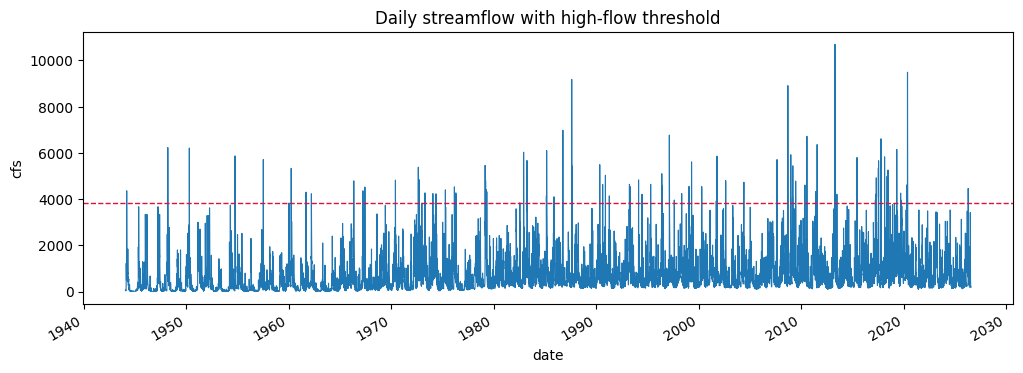

In [18]:
threshold = features.attrs["high_flow_threshold_cfs"]
ax = features.set_index("date")["streamflow_t"].plot(figsize=(12, 4), linewidth=0.8, title="Daily streamflow with high-flow threshold")
ax.axhline(threshold, color="crimson", linestyle="--", linewidth=1)
ax.set_ylabel("cfs")
plt.show()

In [19]:
out_path = ROOT / "data" / "features" / "feature_matrix.parquet"
out_path.parent.mkdir(parents=True, exist_ok=True)
features.to_parquet(out_path, index=False)
out_path

WindowsPath('c:/Users/gandh/OneDrive/Desktop/Uchicago Summer 2026/Project_MLOPS/data/features/feature_matrix.parquet')